In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import proplot as pplt
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyarrow.feather as feather
from scipy.stats import gaussian_kde


import pandas as pd
import geopandas as gpd
# attrs.set_index('gauge_id', inplace=True)

import io
import matplotlib.pyplot as plt
import matplotlib as mpl
import geopandas as gpd
# import proplot as pplt
import matplotlib as mpl
import geopandas as gpd
from matplotlib.ticker import FuncFormatter
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import xarray as xr

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

from pandas import read_feather

import os
import io
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
from tqdm import tqdm


In [4]:
def read_basin_forcing(file_path, expected_columns=None):
    try:
        # Assuming the file has a header with the correct column names
        df = pd.read_csv(file_path, sep='\s+') # , skiprows=3
        # Reindexing only if expected_columns is provided and not matching
        if expected_columns is not None and list(df.columns) != expected_columns:
            df = df.reindex(columns=expected_columns)
        return df
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def import_daymet_forcings(base_folder):
    daymet_folder = os.path.join(base_folder, 'daymet')
    all_data = []
    expected_columns = None  # This will be set after reading the first file

    for root, dirs, files in os.walk(daymet_folder):
        for file in files:
            if file.endswith('_05_model_output.txt'):
                full_path = os.path.join(root, file)
                df = read_basin_forcing(full_path, expected_columns)

                if df is not None:
                    if expected_columns is None:
                        expected_columns = df.columns.tolist()

                    gauge_id = file.split('_')[0]
                    df.insert(0, 'gauge_id', gauge_id)
                    all_data.append(df)

    daymet_ModelOutput_all = pd.concat(all_data, ignore_index=True)
    return daymet_ModelOutput_all

# Update the base folder path as per your directory structure
base_folder = r'F:\Data\CAMELS\basin_timeseries_v1p2_modelOutput_daymet\model_output_daymet\model_output\flow_timeseries'


# Import data using the updated function
daymet_ModelOutput_all = import_daymet_forcings(base_folder)

# Ensure the necessary columns are present before creating the 'Date' column
if all(col in daymet_ModelOutput_all.columns for col in ['YR', 'MNTH', 'DY']):
    # Create a 'Date' column from 'YR', 'MNTH', and 'DY'
    daymet_ModelOutput_all['Date'] = pd.to_datetime(
        daymet_ModelOutput_all['YR'].astype(str) + '-' +
        daymet_ModelOutput_all['MNTH'].astype(str).str.zfill(2) + '-' +
        daymet_ModelOutput_all['DY'].astype(str).str.zfill(2)
    )
    # Drop the original 'YR', 'MNTH', and 'DY' columns
    daymet_ModelOutput_all.drop(['YR', 'MNTH', 'DY', 'HR'], axis=1, inplace=True)
    daymet_ModelOutput_all = daymet_ModelOutput_all[['Date', 'gauge_id', 'SWE', 'PRCP', 'RAIM', 'TAIR', 'PET', 'ET', 'MOD_RUN', 'OBS_RUN']]

# Subsetting with date 1984-01-01':'2014-12-31
daymet_ModelOutput_all.set_index('Date', inplace=True)
daymet_ModelOutput_all.index = pd.to_datetime(daymet_ModelOutput_all.index)
daymet_ModelOutput_all = daymet_ModelOutput_all.sort_index()
daymet_ModelOutput_daily_all = daymet_ModelOutput_all.loc['1984-01-01':'2014-12-31']
daymet_ModelOutput_daily_all.reset_index(inplace=True)
daymet_ModelOutput_daily_all

,Date,gauge_id,SWE,PRCP,RAIM,TAIR,PET,ET,MOD_RUN,OBS_RUN
0,1984-01-01,06224000,370.6266,0.00,0.0300,-9.240,0.2726,0.0662,0.1706,0.1415
1,1984-01-01,08101000,0.0000,0.00,0.0000,3.685,0.9177,0.4961,0.0000,0.0000
2,1984-01-01,06803530,40.5598,6.82,0.1500,-2.070,0.3405,0.3139,0.1437,0.0945
3,1984-01-01,09494000,134.7479,0.00,3.9919,1.990,0.8870,0.8804,0.4496,0.4247
4,1984-01-01,06885500,36.1162,0.00,0.1490,-2.145,0.4122,0.3620,0.0074,0.0622
...,...,...,...,...,...,...,...,...,...,...
8245711,2014-12-31,04213000,1.9501,1.84,0.0500,-6.275,0.2572,0.2550,0.7418,0.8964
8245712,2014-12-31,04213075,2.1420,2.00,0.0500,-6.225,0.2490,0.2473,0.9828,0.6371
8245713,2014-12-31,04216418,5.1459,0.82,0.0551,-8.275,0.1954,0.1942,1.3227,1.0200
8245714,2014-12-31,04122500,0.2396,0.20,0.0500,-10.130,0.1704,0.1687,1.6107,1.1698


In [28]:
import os
import pandas as pd

df = daymet_ModelOutput_daily_all.copy()

df["Date"] = pd.to_datetime(df["Date"])
df["gauge_id"] = df["gauge_id"].astype(str).str.zfill(8)

# Filter 2000–2014
df = df[(df["Date"] >= "2000-01-01") & (df["Date"] <= "2014-12-31")]

# Aggregate daily OBS_RUN to monthly mean for each gauge
df_monthly = (
    df.groupby([
        pd.Grouper(key="Date", freq="MS"),  # month start date
        "gauge_id"
    ])["OBS_RUN"]
    .mean()
    .reset_index()
)

# Pivot: Date as index, gauge_id as columns
Q_USGS = df_monthly.pivot(
    index="Date",
    columns="gauge_id",
    values="OBS_RUN"
)

Q_USGS.columns.name = None

out_path = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather"

Q_USGS_reset = Q_USGS.reset_index()
Q_USGS_reset.to_feather(out_path)

print(f"Saved to: {out_path}")
print(Q_USGS_reset.shape)
print(Q_USGS_reset["Date"].min(), Q_USGS_reset["Date"].max())

Saved to: F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather
(180, 669)
2000-01-01 00:00:00 2014-12-01 00:00:00


In [29]:
pd.read_feather(r'F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\Q_USGS.feather').index

RangeIndex(start=0, stop=180, step=1)

In [25]:
pd.read_feather(r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed\M.feather").index

RangeIndex(start=0, stop=180, step=1)

In [31]:
"""
check_columns.py — Run this to reveal actual column names and time column in each file.
"""
import os
import pandas as pd

DATA_DIR = r"F:\Github_repos\Bayesian_DA_Budyko_modeling\data\processed"

FILES = [
    "PotEvap.feather",
    "Rainf.feather",
    "Q_SACSMA.feather",
    "Q_USGS.feather",
    "M.feather",
    "slope.feather",
]

# Also list ALL feather files in the directory so we see what's actually there
print("=" * 60)
print("ALL .feather files in DATA_DIR:")
print("=" * 60)
for f in sorted(os.listdir(DATA_DIR)):
    if f.endswith(".feather"):
        size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
        print(f"  {f:<40}  {size_mb:.1f} MB")

print()

for fname in FILES:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"\n{'='*60}")
        print(f"NOT FOUND: {fname}")
        continue

    df = pd.read_feather(path)
    print(f"\n{'='*60}")
    print(f"FILE: {fname}   shape={df.shape}")
    print(f"  Index: {df.index.dtype}  values[0:3]={list(df.index[:3])}")
    print(f"  Columns ({len(df.columns)}): {list(df.columns[:10])}")

    # Find candidate time columns
    for col in df.columns:
        if any(k in col.lower() for k in ["time", "date", "year", "month"]):
            sample = df[col].iloc[:3].tolist()
            print(f"  ** Candidate time col '{col}': dtype={df[col].dtype}  sample={sample}")

print("\nDone.")

ALL .feather files in DATA_DIR:
  Evap.feather                              1.2 MB
  M.feather                                 1.2 MB
  NDVI.feather                              1.5 MB
  PotEvap.feather                           1.2 MB
  Q_SACSMA.feather                          1.2 MB
  Q_USGS.feather                            1.2 MB
  Rainf.feather                             1.2 MB
  SFET.feather                              44.7 MB
  slope.feather                             0.3 MB


FILE: PotEvap.feather   shape=(180, 669)
  Index: int64  values[0:3]=[0, 1, 2]
  Columns (669): ['Date', '01013500', '01022500', '01030500', '01031500', '01047000', '01052500', '01054200', '01055000', '01057000']
  ** Candidate time col 'Date': dtype=datetime64[ns]  sample=[Timestamp('2000-01-01 00:00:00'), Timestamp('2000-02-01 00:00:00'), Timestamp('2000-03-01 00:00:00')]

FILE: Rainf.feather   shape=(180, 669)
  Index: int64  values[0:3]=[0, 1, 2]
  Columns (669): ['Date', '01013500', '01022500', '

In [1]:
import os
import pandas as pd
def read_basin_forcing(file_path, expected_columns=None):
    try:
        df = pd.read_csv(file_path, sep='\s+', skiprows=3)
        if expected_columns is not None:
            df = df.reindex(columns=expected_columns)
        return df
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def import_daymet_forcings(base_folder):
    daymet_folder = os.path.join(base_folder, 'daymet')
    all_data = []

    # Sort the directories to process them in order
    # sorted_dirs = sorted(next(os.walk(daymet_folder))[1])
    sorted_dirs = sorted([d for d in os.listdir(daymet_folder) if os.path.isdir(os.path.join(daymet_folder, d))])

    expected_columns = None

    for subdir in sorted_dirs:
        subdir_path = os.path.join(daymet_folder, subdir)
        for file in sorted(os.listdir(subdir_path)):
            if file.endswith('.txt'):
                full_path = os.path.join(subdir_path, file)
                df = read_basin_forcing(full_path, expected_columns)

                if df is not None:
                    if expected_columns is None:
                        expected_columns = df.columns.tolist()

                    df.insert(0, 'gauge_id', os.path.basename(file).split('_')[0])
                    all_data.append(df)

    daymet_forcing_all = pd.concat(all_data, ignore_index=True)
    return daymet_forcing_all

# Import with the above function
import os

base_folder = r"F:\Data\CAMELS\basin_timeseries_v1p2_metForcing_obsFlow\basin_dataset_public_v1p2\basin_mean_forcing"
daymet_forcing_all = import_daymet_forcings(base_folder)



# daymet_forcing_all = import_daymet_forcings(base_folder)

# Drop some columns
# columns_to_drop = ['Hr', 'dayl(s)', 'vp(Pa)', 'srad(W/m2)', 'swe(mm)']
# daymet_forcing_all.drop(columns=columns_to_drop, inplace=True)

daymet_forcing_all.dropna(inplace=True)
# combine 'Year', 'Mnth', and 'Day'
daymet_forcing_all['Date'] = pd.to_datetime(
    daymet_forcing_all['Year'].astype(int).astype(str) + '-' +
    daymet_forcing_all['Mnth'].astype(int).apply(lambda x: f'{x:02d}') + '-' +
    daymet_forcing_all['Day'].astype(int).apply(lambda x: f'{x:02d}')
)

# Drop 'Year', 'Mnth', and 'Day'
daymet_forcing_all.drop(['Year', 'Mnth', 'Day'], axis=1, inplace=True)

# Reindex the DataFrame to place 'Date' at the front
daymet_forcing_all = daymet_forcing_all[['Date', 'gauge_id', 'prcp(mm/day)',	'srad(W/m2)',	'swe(mm)','tmax(C)','tmin(C)',	'vp(Pa)']]
# Make sure Date is datetime
daymet_forcing_all['Date'] = pd.to_datetime(daymet_forcing_all['Date'])

# Set Date as index (needed for resample)
daymet_forcing_all = daymet_forcing_all.set_index('Date')

# Group by gauge_id and resample monthly
daymet_forcing_all_monthly = (
    daymet_forcing_all
    .groupby('gauge_id')
    .resample('M')
    .agg({
        'prcp(mm/day)': 'sum',   # precipitation -> sum
        'srad(W/m2)': 'mean',    # solar radiation -> mean
        'swe(mm)': 'mean',       # SWE -> mean
        'tmax(C)': 'mean',       # Tmax -> mean
        'tmin(C)': 'mean',       # Tmin -> mean
        'vp(Pa)': 'mean'         # vapor pressure -> mean
    })
    .reset_index()
)
daymet_forcing_all_monthly

C:\Users\hdagne1\AppData\Local\Temp\ipykernel_21032\1462649040.py:77: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


,gauge_id,Date,prcp(mm/day),srad(W/m2),swe(mm),tmax(C),tmin(C),vp(Pa)
0,01013500,1980-01-31,46.42,169.483548,0.0,-6.066129,-16.922581,178.982903
1,01013500,1980-02-29,23.88,289.835862,0.0,-6.250345,-18.972069,149.195517
2,01013500,1980-03-31,100.08,348.346774,0.0,0.368065,-11.706774,290.061935
3,01013500,1980-04-30,77.18,428.151667,0.0,9.135667,-1.575333,560.668667
4,01013500,1980-05-31,54.80,496.940968,0.0,16.509677,2.600645,726.139355
...,...,...,...,...,...,...,...,...
283495,14400000,2014-08-31,4.73,423.997097,0.0,25.783548,13.252903,774.225484
283496,14400000,2014-09-30,109.70,336.296667,0.0,23.551000,11.730667,869.588667
283497,14400000,2014-10-31,254.09,213.353226,0.0,18.365806,9.621613,1205.485484
283498,14400000,2014-11-30,196.53,174.885000,0.0,13.334333,6.223667,962.714000


In [2]:
daymet_forcing_all

,gauge_id,prcp(mm/day),srad(W/m2),swe(mm),tmax(C),tmin(C),vp(Pa)
Date,,,,,,,
1980-01-01,01013500,0.00,153.40,0.0,-6.54,-16.30,171.69
1980-01-02,01013500,0.00,145.27,0.0,-6.18,-15.22,185.94
1980-01-03,01013500,0.00,146.96,0.0,-9.89,-18.86,138.39
1980-01-04,01013500,0.00,146.20,0.0,-10.98,-19.76,120.06
1980-01-05,01013500,0.00,170.43,0.0,-11.29,-22.21,117.87
...,...,...,...,...,...,...,...
2014-12-27,11532500,0.00,198.99,0.0,8.59,1.22,667.70
2014-12-28,11532500,2.26,173.72,0.0,7.74,0.53,637.97
2014-12-29,11532500,3.70,136.40,0.0,4.58,-1.17,565.92


In [7]:
import os
import sys
import pandas as pd

# Set this to your project root manually
PROJECT_ROOT = r"F:\Github_repos\Bayesian_DA_Budyko_modeling"

sys.path.append(PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

Rainf_path = os.path.join(DATA_DIR, "Rainf.feather")
PotEvap_path = os.path.join(DATA_DIR, "PotEvap.feather")
Q_usgs_path = os.path.join(DATA_DIR, "Q_USGS.feather")

Rainf_df = pd.read_feather(Rainf_path).set_index("time")
PotEvap_df = pd.read_feather(PotEvap_path).set_index("time")
Q_usgs_df = pd.read_feather(Q_usgs_path).set_index("time")

In [21]:
PotEvap_df.dropna(axis=1)

,06452000,13340000,06447000,06360500,06354000,05057000,07301500,06191500,02315500,06784000,...,12374250,10249300,01350140,14139800,02055100,13018300,01613050,09047700,02038850,09066200
time,,,,,,,,,,,,,,,,,,,,,
2000-01-01,12.843687,3.625935,12.239202,9.951744,8.149305,4.827225,75.642757,7.880135,130.978221,27.534350,...,0.000000,47.772694,34.795781,26.151475,100.186744,0.071228,73.086646,10.387182,86.772760,11.045215
2000-02-01,29.938599,16.271207,26.106276,28.514180,23.937445,16.210544,143.199263,13.046091,178.517231,46.720597,...,1.293996,79.613608,6.118440,39.992447,111.141030,3.122740,53.007159,21.653371,110.861020,19.097587
2000-03-01,106.290388,70.437701,97.590060,101.482607,107.520308,106.441533,166.987692,29.788116,264.618941,125.900581,...,7.679819,150.157545,85.745260,116.142581,212.074836,7.170416,174.268233,27.758427,220.383310,26.482063
2000-04-01,163.689367,161.981997,161.967456,159.650681,168.610688,154.811323,245.492818,101.300781,292.776135,196.162777,...,91.950685,260.144310,136.487759,191.728934,209.478705,64.980350,186.399398,113.696961,211.075370,92.700390
2000-05-01,213.990782,230.122328,212.615382,225.494876,241.136047,223.116934,357.490398,234.651117,419.941119,238.065620,...,249.051109,337.617486,189.838376,221.035782,301.018433,285.720001,257.565763,267.157952,304.681427,202.103528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-08-01,231.650594,278.716649,234.444125,219.802788,199.066243,229.815894,397.079714,196.555719,409.944077,238.314836,...,277.592230,301.940008,214.201911,290.824599,295.674742,213.057704,290.543398,180.268331,328.621675,143.225521
2014-09-01,168.679328,219.983164,161.546749,157.819447,155.629566,167.741106,271.072111,160.958559,242.645883,181.582120,...,194.897291,262.349256,186.235869,239.435101,232.034812,180.613018,255.553633,162.170961,259.115730,120.937320
2014-10-01,124.563594,132.294705,111.989644,108.915041,105.739989,114.119088,217.512600,90.472258,280.039535,147.065453,...,120.740300,172.262406,116.193053,116.475155,197.058153,118.948647,185.747858,117.112761,211.903884,78.264956


 Ensemble Kalman Filter – Rainfall-Runoff Demo
  State dim     : 3
  Obs dim       : 1
  Time steps    : 50
  Ensemble size : 30
  Meas. noise σ : 0.5
  Inflation σ   : 1.0

Step 1/3: Generating synthetic data ...
Step 2/3: Running EnKF ...
Step 3/3: Evaluating results ...

─── RMSE Summary ───────────────────────────────
  Simulation (no EnKF) RMSE : 6.9012
  EnKF posterior mean  RMSE : 4.8133
  Improvement          : 30.3%
────────────────────────────────────────────────



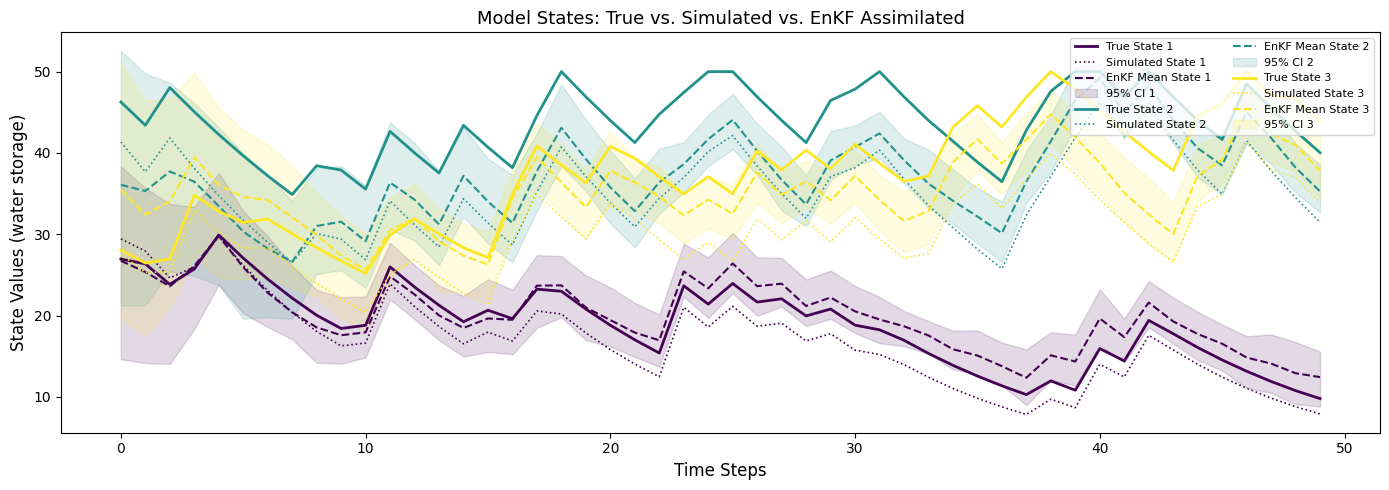

Saved: enkf_states.png


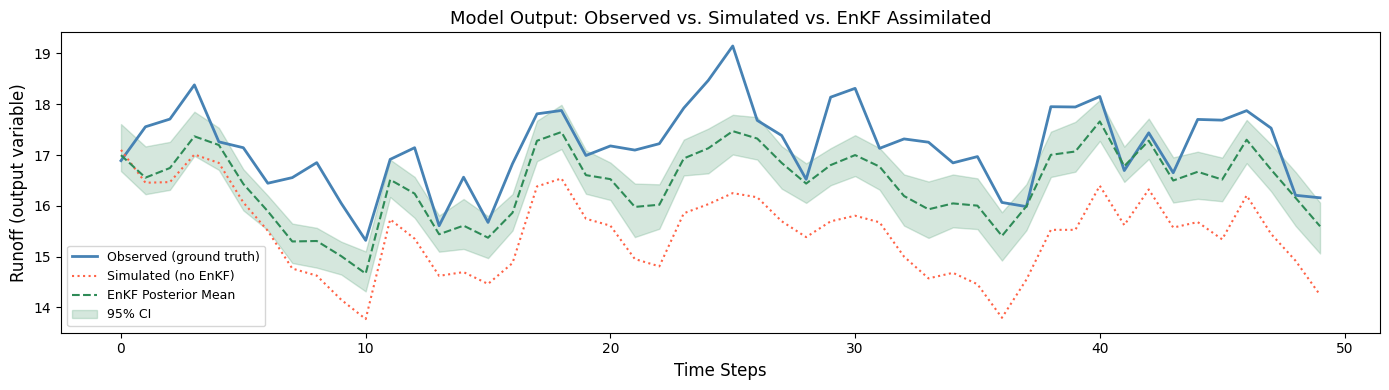

Saved: enkf_output.png
Done! Figures saved to /mnt/user-data/outputs/


In [15]:
"""
Ensemble Kalman Filter (EnKF) - Complete Implementation
Based on: "Addressing the Butterfly Effect: Data Assimilation Using Ensemble Kalman Filter"
by Wencong Yang, PhD

This script implements the full EnKF pipeline applied to a rainfall-runoff modeling case study.
"""

import numpy as np
from numpy.typing import NDArray
from typing import Tuple
import matplotlib.pyplot as plt


# ─────────────────────────────────────────────────────────────────────────────
# 1. ENKF CORE FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def enkf_update(
    ensemble: NDArray,
    observation: NDArray,
    model: callable,
    obs_operator: callable,
    R: NDArray,
    **kwargs
) -> NDArray:
    """
    Perform one EnKF update step.

    Parameters
    ----------
    ensemble     : (ensemble_size, state_dim) – current posterior ensemble
    observation  : (y_dim,) – observed output at this time step
    model        : state transition function  x_{t+1} = model(x_t, **kwargs)
    obs_operator : observation operator       y = obs_operator(x)
    R            : (y_dim, y_dim) – observation error covariance matrix
    **kwargs     : extra inputs forwarded to the state transition model

    Returns
    -------
    update_ensemble : (ensemble_size, state_dim) – updated posterior ensemble
    """
    ensemble_size = ensemble.shape[0]

    # ── Forecast step ─────────────────────────────────────────────────────────
    forecast_ensemble = np.array([model(state, **kwargs) for state in ensemble])
    H_ensemble = np.array([obs_operator(state) for state in forecast_ensemble])

    # ── Empirical covariances ─────────────────────────────────────────────────
    # P_f_xy : cross-covariance between state and observation space  (state_dim, y_dim)
    # P_f_yy : covariance in observation space                       (y_dim, y_dim)
    dx = forecast_ensemble - forecast_ensemble.mean(axis=0)   # (N, state_dim)
    dy = H_ensemble - H_ensemble.mean(axis=0)                 # (N, y_dim)

    P_f_xy = dx.T @ dy / (ensemble_size - 1)                  # (state_dim, y_dim)
    P_f_yy = np.cov(H_ensemble.T)                             # (y_dim, y_dim)

    # Scalar edge case: np.cov returns a 0-d array for 1-D input
    if P_f_yy.ndim == 0:
        P_f_yy = P_f_yy.reshape(1, 1)

    # ── Kalman gain ───────────────────────────────────────────────────────────
    # K = P_f_xy · (P_f_yy + R)^{-1}   shape: (state_dim, y_dim)
    K = P_f_xy @ np.linalg.inv(P_f_yy + R)

    # ── Analysis step ─────────────────────────────────────────────────────────
    update_ensemble = np.empty_like(forecast_ensemble)
    for i in range(ensemble_size):
        innovation = observation - H_ensemble[i]               # (y_dim,)
        update_ensemble[i] = forecast_ensemble[i] + K @ innovation

    return update_ensemble


def enkf_loop(
    initial_ensemble: NDArray,
    observations_y: NDArray,
    R: NDArray,
    model: callable,
    obs_operator: callable,
    model_input: dict,
    inflation_noise_std: float
) -> NDArray:
    """
    Run EnKF over all time steps.

    Parameters
    ----------
    initial_ensemble    : (ensemble_size, state_dim)
    observations_y      : (time_steps, y_dim)
    R                   : (y_dim, y_dim)
    model               : state transition callable
    obs_operator        : observation operator callable
    model_input         : dict of arrays shaped (time_steps, *), e.g. {"rainfall": ..., "evap_coeff": ...}
    inflation_noise_std : std-dev of additive inflation noise (prevents ensemble collapse)

    Returns
    -------
    ensemble_history : (time_steps, ensemble_size, state_dim)
    """
    time_steps = observations_y.shape[0]
    ensemble = initial_ensemble.copy()
    ensemble_history = []

    for t in range(time_steps):
        observation = observations_y[t]
        step_model_input = {k: v[t] for k, v in model_input.items()}

        ensemble = enkf_update(
            ensemble=ensemble,
            observation=observation,
            model=model,
            obs_operator=obs_operator,
            R=R,
            **step_model_input
        )

        # Covariance inflation: add small noise to prevent ensemble collapse
        ensemble += np.random.normal(0, inflation_noise_std, size=ensemble.shape)

        ensemble_history.append(ensemble.copy())

    return np.array(ensemble_history)   # (time_steps, ensemble_size, state_dim)


# ─────────────────────────────────────────────────────────────────────────────
# 2. RAINFALL-RUNOFF MODELS (TRUE vs. APPROXIMATE)
# ─────────────────────────────────────────────────────────────────────────────

def true_state_transition(
    states: NDArray,
    rainfall: NDArray,
    evap_coeff: NDArray
) -> NDArray:
    """Ground-truth (hidden) state transition."""
    updated = states + rainfall - evap_coeff * states
    updated = np.clip(updated, 0, 50)
    return updated


def true_observation_operator(states: NDArray, measure_noise_std: float) -> NDArray:
    """Ground-truth observation operator with measurement noise."""
    y = np.array([(np.clip(states, 0, None) ** 0.5).sum()])
    y += np.random.normal(0, measure_noise_std, size=y.shape)
    return y


def state_transition(
    states: NDArray,
    rainfall: NDArray,
    evap_coeff: NDArray
) -> NDArray:
    """Approximate (biased) state transition used in the filter."""
    updated = states ** 0.99 * 1.01 + rainfall * 1.02 - evap_coeff * states
    updated = np.clip(updated, 0, 50)
    return updated


def observation_operator(states: NDArray) -> NDArray:
    """Approximate (noise-free) observation operator used in the filter."""
    return np.array([(np.clip(states, 0, None) ** 0.5).sum()])


# ─────────────────────────────────────────────────────────────────────────────
# 3. SYNTHETIC DATA GENERATION
# ─────────────────────────────────────────────────────────────────────────────

def generate_data(time_steps: int, state_dim: int, measure_noise_std: float):
    """
    Generate synthetic ground-truth states, observations, and model simulations.

    Returns
    -------
    rainfall_data   : (time_steps, state_dim)
    evap_coef_data  : (time_steps, state_dim)
    true_states     : (time_steps, state_dim)
    sim_states      : (time_steps, state_dim)
    observations_y  : (time_steps, y_dim)
    simulations_y   : (time_steps, y_dim)
    """
    np.random.seed(42)  # reproducibility

    # External inputs
    rainfall_data = np.random.uniform(0, 20, size=(time_steps, state_dim))
    rainfall_data = (rainfall_data - 10).clip(min=0)

    evap_coef_data = np.random.uniform(0.05, 0.1, size=state_dim)
    evap_coef_data = np.tile(evap_coef_data, (time_steps, 1))   # (time_steps, state_dim)

    # Initial states
    true_state_list = [np.random.uniform(20, 40, size=state_dim)]
    sim_state_list  = [np.random.uniform(20, 40, size=state_dim)]

    obs_y_list, sim_y_list = [], []

    for t in range(time_steps):
        # True (hidden) dynamics
        true_state = true_state_transition(true_state_list[-1], rainfall_data[t], evap_coef_data[t])
        true_state_list.append(true_state)

        # Approximate (model) dynamics
        sim_state = state_transition(sim_state_list[-1], rainfall_data[t], evap_coef_data[t])
        sim_state_list.append(sim_state)

        # Observations (from true state + noise) and model output
        obs_y_list.append(true_observation_operator(true_state, measure_noise_std))
        sim_y_list.append(observation_operator(sim_state))

    true_states    = np.array(true_state_list)[1:]   # (time_steps, state_dim)
    sim_states     = np.array(sim_state_list)[1:]
    observations_y = np.array(obs_y_list)            # (time_steps, y_dim)
    simulations_y  = np.array(sim_y_list)

    return rainfall_data, evap_coef_data, true_states, sim_states, observations_y, simulations_y


# ─────────────────────────────────────────────────────────────────────────────
# 4. PLOTTING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def plot_states(true_states, sim_states, ensemble_history, time_steps, state_dim):
    posterior_mean = ensemble_history.mean(axis=1)          # (T, state_dim)
    ci_lower = np.percentile(ensemble_history, 2.5, axis=1)
    ci_upper = np.percentile(ensemble_history, 97.5, axis=1)
    colors = plt.cm.viridis(np.linspace(0, 1, state_dim))
    t_axis = np.arange(time_steps)

    plt.figure(figsize=(14, 5))
    for i in range(state_dim):
        c = colors[i]
        plt.plot(t_axis, true_states[:, i],        color=c, lw=2,   label=f"True State {i+1}")
        plt.plot(t_axis, sim_states[:, i],          color=c, lw=1.2, linestyle="dotted",  label=f"Simulated State {i+1}")
        plt.plot(t_axis, posterior_mean[:, i],      color=c, lw=1.5, linestyle="dashed",  label=f"EnKF Mean State {i+1}")
        plt.fill_between(t_axis, ci_lower[:, i], ci_upper[:, i], alpha=0.15, color=c, label=f"95% CI {i+1}")

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("State Values (water storage)", fontsize=12)
    plt.title("Model States: True vs. Simulated vs. EnKF Assimilated", fontsize=13)
    plt.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout()
    # plt.savefig("/mnt/user-data/outputs/enkf_states.png", dpi=150)
    plt.show()
    print("Saved: enkf_states.png")


def plot_output(observations_y, simulations_y, ensemble_history, time_steps, y_dim):
    # Compute posterior output from each ensemble member
    posterior_y = np.zeros((time_steps, ensemble_history.shape[1], y_dim))
    for t in range(time_steps):
        for i in range(ensemble_history.shape[1]):
            posterior_y[t, i] = observation_operator(ensemble_history[t, i])

    posterior_mean_y = posterior_y.mean(axis=1)
    ci_lower_y = np.percentile(posterior_y, 2.5, axis=1)
    ci_upper_y = np.percentile(posterior_y, 97.5, axis=1)
    t_axis = np.arange(time_steps)

    plt.figure(figsize=(14, 4))
    for i in range(y_dim):
        plt.plot(t_axis, observations_y[:, i],    color="steelblue", lw=2,   label="Observed (ground truth)")
        plt.plot(t_axis, simulations_y[:, i],     color="tomato",    lw=1.5, linestyle="dotted",  label="Simulated (no EnKF)")
        plt.plot(t_axis, posterior_mean_y[:, i],  color="seagreen",  lw=1.5, linestyle="dashed",  label="EnKF Posterior Mean")
        plt.fill_between(t_axis, ci_lower_y[:, i], ci_upper_y[:, i], alpha=0.2, color="seagreen", label="95% CI")

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Runoff (output variable)", fontsize=12)
    plt.title("Model Output: Observed vs. Simulated vs. EnKF Assimilated", fontsize=13)
    plt.legend(fontsize=9)
    plt.tight_layout()
    # plt.savefig("/mnt/user-data/outputs/enkf_output.png", dpi=150)
    plt.show()
    print("Saved: enkf_output.png")


def print_rmse(true_states, sim_states, ensemble_history):
    posterior_mean = ensemble_history.mean(axis=1)
    rmse_sim  = np.sqrt(np.mean((sim_states   - true_states) ** 2))
    rmse_enkf = np.sqrt(np.mean((posterior_mean - true_states) ** 2))
    print("\n─── RMSE Summary ───────────────────────────────")
    print(f"  Simulation (no EnKF) RMSE : {rmse_sim:.4f}")
    print(f"  EnKF posterior mean  RMSE : {rmse_enkf:.4f}")
    improvement = (rmse_sim - rmse_enkf) / rmse_sim * 100
    print(f"  Improvement          : {improvement:.1f}%")
    print("────────────────────────────────────────────────\n")


# ─────────────────────────────────────────────────────────────────────────────
# 5. MAIN: RUN THE FULL EXPERIMENT
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Hyperparameters ───────────────────────────────────────────────────────
    STATE_DIM         = 3       # number of bucket compartments (state variables)
    Y_DIM             = 1       # number of observable outputs (runoff)
    TIME_STEPS        = 50      # simulation length
    ENSEMBLE_SIZE     = 30      # number of Monte Carlo ensemble members
    MEASURE_NOISE_STD = 0.5     # observation noise std-dev
    INFLATION_STD     = 1.0     # ensemble inflation noise std-dev

    print("=" * 55)
    print(" Ensemble Kalman Filter – Rainfall-Runoff Demo")
    print("=" * 55)
    print(f"  State dim     : {STATE_DIM}")
    print(f"  Obs dim       : {Y_DIM}")
    print(f"  Time steps    : {TIME_STEPS}")
    print(f"  Ensemble size : {ENSEMBLE_SIZE}")
    print(f"  Meas. noise σ : {MEASURE_NOISE_STD}")
    print(f"  Inflation σ   : {INFLATION_STD}\n")

    # ── 1. Generate data ──────────────────────────────────────────────────────
    print("Step 1/3: Generating synthetic data ...")
    rainfall_data, evap_coef_data, true_states, sim_states, observations_y, simulations_y = \
        generate_data(TIME_STEPS, STATE_DIM, MEASURE_NOISE_STD)

    # ── 2. Set up and run EnKF ────────────────────────────────────────────────
    print("Step 2/3: Running EnKF ...")
    np.random.seed(0)

    R = np.diag(np.full(Y_DIM, MEASURE_NOISE_STD ** 2))        # observation error covariance
    initial_ensemble = np.random.uniform(10, 50, size=(ENSEMBLE_SIZE, STATE_DIM))

    model_input = {
        "rainfall"   : rainfall_data,
        "evap_coeff" : evap_coef_data,
    }

    ensemble_history = enkf_loop(
        initial_ensemble=initial_ensemble,
        observations_y=observations_y,
        R=R,
        model=state_transition,
        obs_operator=observation_operator,
        model_input=model_input,
        inflation_noise_std=INFLATION_STD,
    )
    # ensemble_history shape: (time_steps, ensemble_size, state_dim)

    # ── 3. Evaluate and plot ──────────────────────────────────────────────────
    print("Step 3/3: Evaluating results ...")
    print_rmse(true_states, sim_states, ensemble_history)

    plot_states(true_states, sim_states, ensemble_history, TIME_STEPS, STATE_DIM)
    plot_output(observations_y, simulations_y, ensemble_history, TIME_STEPS, Y_DIM)

    print("Done! Figures saved to /mnt/user-data/outputs/")
